In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set1_f.csv", encoding='cp949')
df.head()  # 처음 5행 미리보기
df.info()  # 컬럼 이름, 타입, 결측치 정보 확인


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4185 non-null   object 
 1   MCT_BSE_AR          4185 non-null   object 
 2   MCT_NM              4185 non-null   object 
 3   MCT_BRD_NUM         542 non-null    object 
 4   MCT_SIGUNGU_NM      4185 non-null   object 
 5   HPSN_MCT_ZCD_NM     4185 non-null   object 
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object 
 7   ARE_D               4185 non-null   int64  
 8   MCT_ME_D            127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set2_f.csv", encoding='cp949')
df.head()  # 처음 5행 미리보기
df.info()  # 컬럼 이름, 타입, 결측치 정보 확인


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   가맹점구분번호            86590 non-null  object 
 1   기준년월               86590 non-null  int64  
 2   가맹점 운영개월수 구간       86590 non-null  object 
 3   매출금액 구간            86590 non-null  object 
 4   매출건수 구간            86590 non-null  object 
 5   유니크 고객 수 구간        86590 non-null  object 
 6   객단가 구간             86590 non-null  object 
 7   취소율 구간             79958 non-null  object 
 8   배달매출금액 비율          86590 non-null  float64
 9   동일 업종 매출금액 비율      86590 non-null  float64
 10  동일 업종 매출건수 비율      86590 non-null  float64
 11  동일 업종 내 매출 순위 비율   86590 non-null  float64
 12  동일 상권 내 매출 순위 비율   86590 non-null  float64
 13  동일 업종 내 해지 가맹점 비중  86590 non-null  float64
 14  동일 상권 내 해지 가맹점 비중  86590 non-null  float64
dtypes: float64(7), int64(1), object(7)
memory usage: 9.9+ MB


In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set3_f.csv", encoding='cp949')
df.head()  # 처음 5행 미리보기
df.info()  # 컬럼 이름, 타입, 결측치 정보 확인


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  int64  
 2   M12_MAL_1020_RAT          86590 non-null  float64
 3   M12_MAL_30_RAT            86590 non-null  float64
 4   M12_MAL_40_RAT            86590 non-null  float64
 5   M12_MAL_50_RAT            86590 non-null  float64
 6   M12_MAL_60_RAT            86590 non-null  float64
 7   M12_FME_1020_RAT          86590 non-null  float64
 8   M12_FME_30_RAT            86590 non-null  float64
 9   M12_FME_40_RAT            86590 non-null  float64
 10  M12_FME_50_RAT            86590 non-null  float64
 11  M12_FME_60_RAT            86590 non-null  float64
 12  MCT_UE_CLN_REU_RAT        86590 non-null  float64
 13  MCT_UE_CLN_NEW_RAT        86590 non-null  float64
 14  RC_M1_

In [7]:
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- 데이터 불러오기  ---
df1 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set1_f.csv", encoding='cp949')
df2 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set2_f.csv", encoding='cp949')
df3 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set3_f.csv", encoding='cp949')

# --- 데이터 통합을 위한 전처리 ---
# df2의 컬럼명을 df1, df3와 통일
df2.rename(columns={'가맹점구분번호': 'ENCODED_MCT', '기준년월': 'TA_YM'}, inplace=True)

# --- 데이터프레임 병합 ---
# df2와 df3를 먼저 합칩니다. (가맹점 ID와 년월 기준)
merged_df = pd.merge(df2, df3, on=['ENCODED_MCT', 'TA_YM'], how='inner')

# 위 결과에 df1(가맹점 정보)을 합침
final_df = pd.merge(merged_df, df1, on='ENCODED_MCT', how='left')

# 날짜 형식으로 변환 및 정렬
final_df['TA_YM'] = pd.to_datetime(final_df['TA_YM'], format='%Y%m')
final_df = final_df.sort_values(by='TA_YM')


print(final_df.head())
print(final_df.info())

      ENCODED_MCT      TA_YM        가맹점 운영개월수 구간   매출금액 구간   매출건수 구간  \
29673  33EF2536AD 2023-01-01            4_50-75%  3_25-50%  4_50-75%   
81983  3D972997F9 2023-01-01            4_50-75%  5_75-90%  5_75-90%   
82902  DF334CC79E 2023-01-01            3_25-50%  3_25-50%  4_50-75%   
84794  1389DE67CE 2023-01-01  6_90%초과(하위 10% 이하)  3_25-50%   1_10%이하   
19156  B3628DE20B 2023-01-01  6_90%초과(하위 10% 이하)  2_10-25%  2_10-25%   

      유니크 고객 수 구간    객단가 구간   취소율 구간  배달매출금액 비율  동일 업종 매출금액 비율  ...  \
29673    4_50-75%  3_25-50%  1_상위1구간  -999999.9           97.0  ...   
81983    5_75-90%  3_25-50%  1_상위1구간       81.8           18.0  ...   
82902    3_25-50%  2_10-25%  1_상위1구간       19.2          173.7  ...   
84794    2_10-25%  5_75-90%  2_상위2구간        5.6          217.5  ...   
19156    2_10-25%  4_50-75%  2_상위2구간  -999999.9          101.4  ...   

       RC_M1_SHC_WP_UE_CLN_RAT  RC_M1_SHC_FLP_UE_CLN_RAT  \
29673                      5.1                      41.0   
81983               

In [10]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정을 위해 matplotlib의 rcParams를 조정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 데이터 불러오기 ---
df1 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set1_f.csv", encoding='cp949')
df2 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set2_f.csv", encoding='cp949')
df3 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set3_f.csv", encoding='cp949')

# --- 2. 데이터 통합 ---
df2.rename(columns={'가맹점구분번호': 'ENCODED_MCT', '기준년월': 'TA_YM'}, inplace=True)
merged_df = pd.merge(df2, df3, on=['ENCODED_MCT', 'TA_YM'], how='inner')
final_df = pd.merge(merged_df, df1, on='ENCODED_MCT', how='left')
final_df['TA_YM'] = pd.to_datetime(final_df['TA_YM'], format='%Y%m')
final_df = final_df.sort_values(by='TA_YM')

# --- 3. 데이터 전처리 ---
# 3-1. 특이값(-999999.9)을 결측치(np.nan)로 변환
final_df['배달매출금액 비율'] = final_df['배달매출금액 비율'].replace(-999999.9, np.nan)


# 3-2. [수정됨] 고객 비율 데이터 클리닝 (모든 음수 값을 결측치로 처리)
ratio_columns_to_clean = ['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']
for col in ratio_columns_to_clean:
    # 0보다 작은 값을 가지는 행을 찾아 np.nan으로 변경
    final_df[col] = final_df[col].apply(lambda x: x if x >= 0 else np.nan)


# 3-3. '구간' 데이터를 숫자 데이터로 변환하는 함수 정의
def convert_range_to_numeric(range_str):
    if pd.isna(range_str):
        return np.nan
    numbers = re.findall(r'\d+', str(range_str))
    if not numbers:
        return np.nan
    elif len(numbers) >= 2:
        return (float(numbers[-2]) + float(numbers[-1])) / 2
    else:
        return float(numbers[0])

columns_to_convert = [
    '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', 
    '유니크 고객 수 구간', '객단가 구간', '취소율 구간'
]
for col in columns_to_convert:
    new_col_name = f"{col.replace(' 구간', '')}_수치"
    final_df[new_col_name] = final_df[col].apply(convert_range_to_numeric)

def categorize_biz(업종명):
    if pd.isna(업종명):
        return '기타'
    # 한식
    if ('한식' in 업종명) or (업종명 in [
        '백반/가정식', '한정식', '기사식당', '한식-육류/고기', '한식-찌개/전골',
        '한식-국수/만두', '한식-단품요리일반', '한식-해물/생선', '한식-냉면',
        '한식-국밥/설렁탕', '한식-감자탕', '한식-죽', '한식-두부요리', '한식뷔페'
    ]):
        return '한식'
    # 음식점
    elif ('식당' in 업종명) or (업종명 in [
        '양식', '중식당', '중식-훠궈/마라탕', '중식-딤섬/중식만두', '일식당', 
        '일식-덮밥/돈가스', '일식-우동/소바/라면', '일식-초밥/롤', '일식-샤브샤브', 
        '일식-참치회', '분식', '치킨', '피자', '햄버거', '스테이크',
        '샌드위치/토스트', '도시락', '동남아/인도음식', '기타세계요리', '구내식당/푸드코트'
    ]):
        return '음식점'
    # 카페/디저트
    elif ('카페' in 업종명) or (업종명 in [
        '커피전문점', '테이크아웃커피', '테마카페', '카페', '아이스크림/빙수', 
        '베이커리', '베이 커리', '도너츠', '마카롱', '와플/크로플', '차', '주스', '탕후루'
    ]):
        return '카페/디저트'
    # 주류/유흥
    elif ('주점' in 업종명) or (업종명 in [
        '호프/맥주', '이자카야', '포장마차', '와인바', '와인샵', '룸살롱/단란주점', 
        '일반 유흥주점', '꼬치구이', '요리주점', '민속주점', '주류'
    ]):
        return '주류/유흥'
    # 식료품/소매
    elif ('식료품' in 업종명) or (업종명 in [
        '축산물', '농산물', '수산물', '청과물', '미곡상', '반찬', '떡/한과', 
        '떡/한과 제조', '유제품', '식품 제조', '인삼제품', '건강식품', '건강원', '건어물', '담배'
    ]):
        return '식료품/소매'
    # 기타
    else:
        return '기타'

# final_df에 있는 업종명 컬럼('HPSN_MCT_BZN_CD_NM')을 사용해 '대분류' 컬럼을 생성합니다.
final_df['대분류'] = final_df['HPSN_MCT_ZCD_NM'].apply(categorize_biz)


# --- 4. 최종 데이터 확인 ---
print("\n[최종 데이터 샘플 확인]")
# '대분류' 컬럼이 잘 추가되었는지 확인합니다.
print(final_df[['HPSN_MCT_BZN_CD_NM', '대분류', 'MCT_UE_CLN_REU_RAT']])
# print(final_df[['HPSN_MCT_BZN_CD_NM', '대분류', 'MCT_UE_CLN_REU_RAT']].head())

print("\n[최종 데이터 정보 요약]")
final_df.info()

# --- 4. 최종 처리 결과 확인 ---
print("\n[고객 비율 데이터 클리닝 확인 (describe)]")
# 최소값(min)이 0 이상인지 확인하여 음수 값이 모두 제거되었는지 검증합니다.
print(final_df[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].describe())

print(final_df.head())
print(final_df.info())



[최종 데이터 샘플 확인]
      HPSN_MCT_BZN_CD_NM     대분류  MCT_UE_CLN_REU_RAT
29673                NaN      한식               38.82
81983                NaN      한식               11.25
82902                답십리      한식               15.86
84794               금남시장  카페/디저트               35.23
19156                 옥수   주류/유흥               14.58
...                  ...     ...                 ...
78380                NaN  카페/디저트               22.62
40331                 뚝섬      한식               20.22
59878                 성수  식료품/소매               14.96
78369                 뚝섬     음식점                9.36
34868                답십리     음식점               16.67

[86279 rows x 3 columns]

[최종 데이터 정보 요약]
<class 'pandas.core.frame.DataFrame'>
Index: 86279 entries, 29673 to 34868
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ENCODED_MCT               86279 non-null  object        
 1   TA_YM  

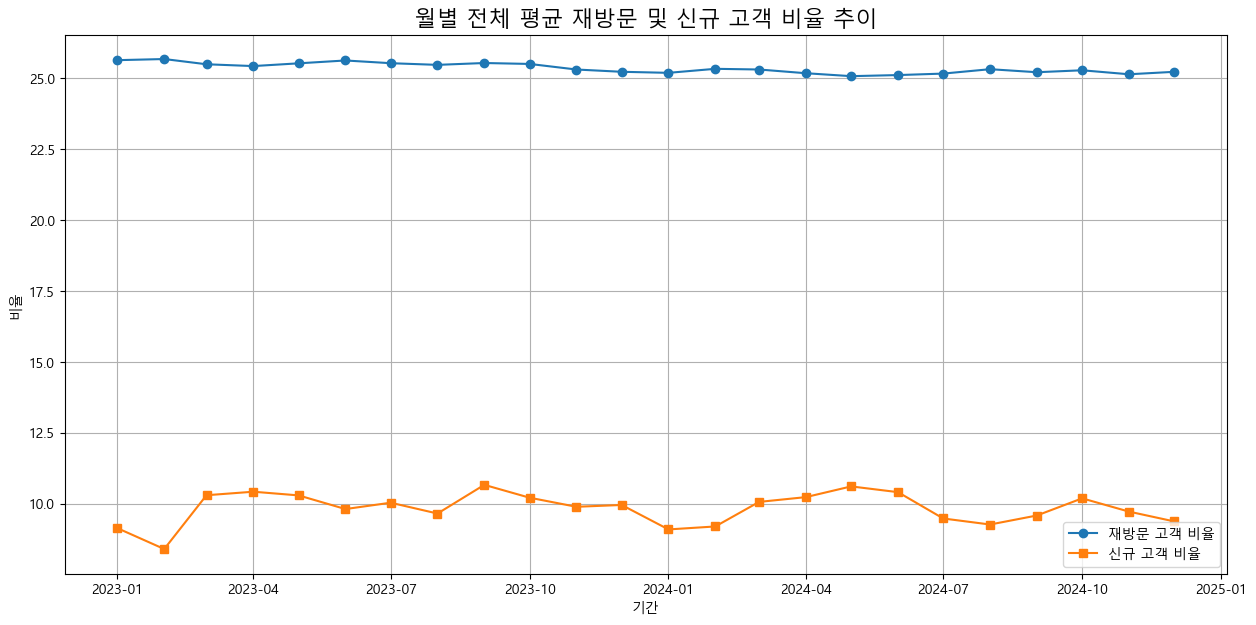

In [11]:
# 월별 평균 재방문/신규 고객 비율 계산
monthly_trends = final_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean().reset_index()

# 시각화
plt.figure(figsize=(15, 7))

plt.plot(monthly_trends['TA_YM'], monthly_trends['MCT_UE_CLN_REU_RAT'], marker='o', label='재방문 고객 비율')
plt.plot(monthly_trends['TA_YM'], monthly_trends['MCT_UE_CLN_NEW_RAT'], marker='s', label='신규 고객 비율')

plt.title('월별 전체 평균 재방문 및 신규 고객 비율 추이', fontsize=16)
plt.xlabel('기간')
plt.ylabel('비율')
plt.legend()
plt.grid(True)
plt.show()

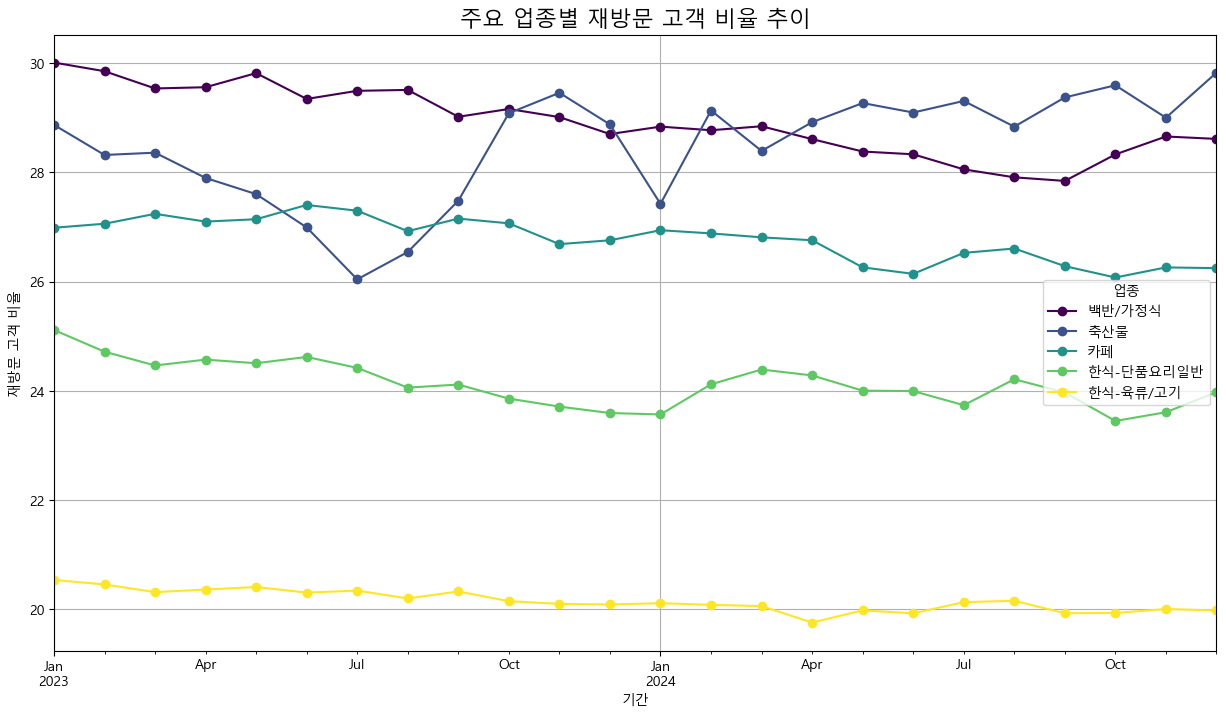

In [12]:
# 3-1. 주요 업종별 재방문 고객 비율 비교
# 주요 업종 5개 선정 (가맹점 수가 많은 순)
top5_bzn = final_df['HPSN_MCT_ZCD_NM'].value_counts().head(5).index

# 상위 5개 업종 데이터 필터링
bzn_df = final_df[final_df['HPSN_MCT_ZCD_NM'].isin(top5_bzn)]

# 업종별, 월별 평균 재방문 고객 비율 계산
bzn_trends = bzn_df.groupby(['TA_YM', 'HPSN_MCT_ZCD_NM'])['MCT_UE_CLN_REU_RAT'].mean().unstack()


# 시각화
bzn_trends.plot(figsize=(15, 8), marker='o', colormap='viridis')
plt.title('주요 업종별 재방문 고객 비율 추이', fontsize=16)
plt.xlabel('기간')
plt.ylabel('재방문 고객 비율')
plt.legend(title='업종')
plt.grid(True)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정을 위해 matplotlib의 rcParams를 조정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 데이터 불러오기 ---
df1 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set1_f.csv", encoding='cp949')
df2 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set2_f.csv", encoding='cp949')
df3 = pd.read_csv(r"C:\Users\lisaj\OneDrive\바탕 화면\big_data_set3_f.csv", encoding='cp949')

# --- 2. 데이터 통합 ---
df2.rename(columns={'가맹점구분번호': 'ENCODED_MCT', '기준년월': 'TA_YM'}, inplace=True)
merged_df = pd.merge(df2, df3, on=['ENCODED_MCT', 'TA_YM'], how='inner')
final_df = pd.merge(merged_df, df1, on='ENCODED_MCT', how='left')
final_df['TA_YM'] = pd.to_datetime(final_df['TA_YM'], format='%Y%m')
final_df = final_df.sort_values(by='TA_YM')

# --- 3. 데이터 전처리 ---
# (이전 전처리 코드는 동일합니다)
final_df['배달매출금액 비율'] = final_df['배달매출금액 비율'].replace(-999999.9, np.nan)
ratio_columns_to_clean = ['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']
for col in ratio_columns_to_clean:
    final_df[col] = final_df[col].apply(lambda x: x if x >= 0 else np.nan)

def convert_range_to_numeric(range_str):
    if pd.isna(range_str): return np.nan
    numbers = re.findall(r'\d+', str(range_str))
    if not numbers: return np.nan
    elif len(numbers) >= 2: return (float(numbers[-2]) + float(numbers[-1])) / 2
    else: return float(numbers[0])

columns_to_convert = [
    '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', 
    '유니크 고객 수 구간', '객단가 구간', '취소율 구간'
]
for col in columns_to_convert:
    new_col_name = f"{col.replace(' 구간', '')}_수치"
    final_df[new_col_name] = final_df[col].apply(convert_range_to_numeric)

# --- 4. 대분류 생성 ---
def categorize_biz(업종명):
    if pd.isna(업종명): return '기타'
    if ('한식' in 업종명) or (업종명 in [
        '백반/가정식', '한정식', '기사식당', '한식-육류/고기', '한식-찌개/전골',
        '한식-국수/만두', '한식-단품요리일반', '한식-해물/생선', '한식-냉면',
        '한식-국밥/설렁탕', '한식-감자탕', '한식-죽', '한식-두부요리', '한식뷔페'
    ]): return '한식'
    elif ('식당' in 업종명) or (업종명 in [
        '양식', '중식당', '중식-훠궈/마라탕', '중식-딤섬/중식만두', '일식당', '일식-덮밥/돈가스', 
        '일식-우동/소바/라면', '일식-초밥/롤', '일식-샤브샤브', '일식-참치회', '분식', '치킨', 
        '피자', '햄버거', '스테이크', '샌드위치/토스트', '도시락', '동남아/인도음식', 
        '기타세계요리', '구내식당/푸드코트'
    ]): return '음식점'
    elif ('카페' in 업종명) or (업종명 in [
        '커피전문점', '테이크아웃커피', '테마카페', '카페', '아이스크림/빙수', '베이커리', 
        '베이 커리', '도너츠', '마카롱', '와플/크로플', '차', '주스', '탕후루'
    ]): return '카페/디저트'
    elif ('주점' in 업종명) or (업종명 in [
        '호프/맥주', '이자카야', '포장마차', '와인바', '와인샵', '룸살롱/단란주점', 
        '일반 유흥주점', '꼬치구이', '요리주점', '민속주점', '주류'
    ]): return '주류/유흥'
    elif ('식료품' in 업종명) or (업종명 in [
        '축산물', '농산물', '수산물', '청과물', '미곡상', '반찬', '떡/한과', '떡/한과 제조', 
        '유제품', '식품 제조', '인삼제품', '건강식품', '건강원', '건어물', '담배'
    ]): return '식료품/소매'
    else: return '기타'

# ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
final_df['대분류'] = final_df['HPSN_MCT_ZCD_NM'].apply(categorize_biz)
# ★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

print("✅ '대분류' 컬럼이 올바른 컬럼을 사용하여 성공적으로 생성되었습니다.")

# --- 5. 최종 확인 ---
print("\n[대분류 생성 결과 확인]")
print(final_df['대분류'].value_counts())


✅ '대분류' 컬럼이 올바른 컬럼을 사용하여 성공적으로 생성되었습니다.

[대분류 생성 결과 확인]
대분류
한식        30513
음식점       18751
카페/디저트    15060
식료품/소매    14296
주류/유흥      7659
Name: count, dtype: int64


✅ '음식점' 대분류로 필터링된 데이터 개수: 18751 개


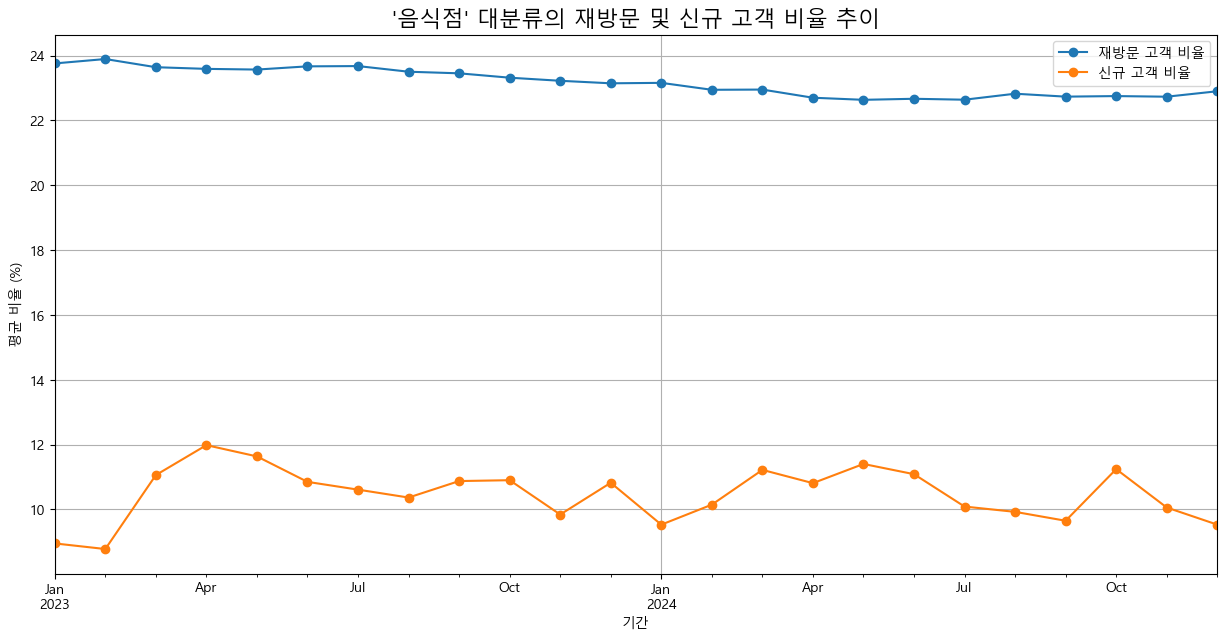

In [14]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '음식점'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()

    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")

✅ '한식' 대분류로 필터링된 데이터 개수: 30513 개


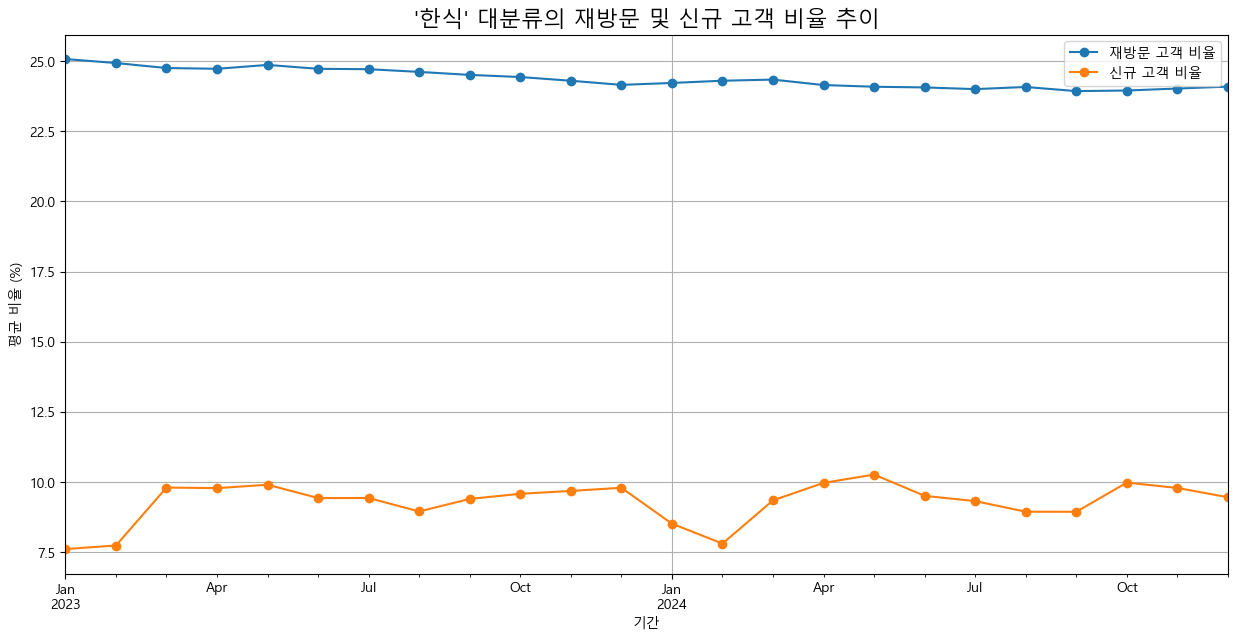

In [15]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '한식'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()

    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")


✅ '카페/디저트' 대분류로 필터링된 데이터 개수: 15060 개


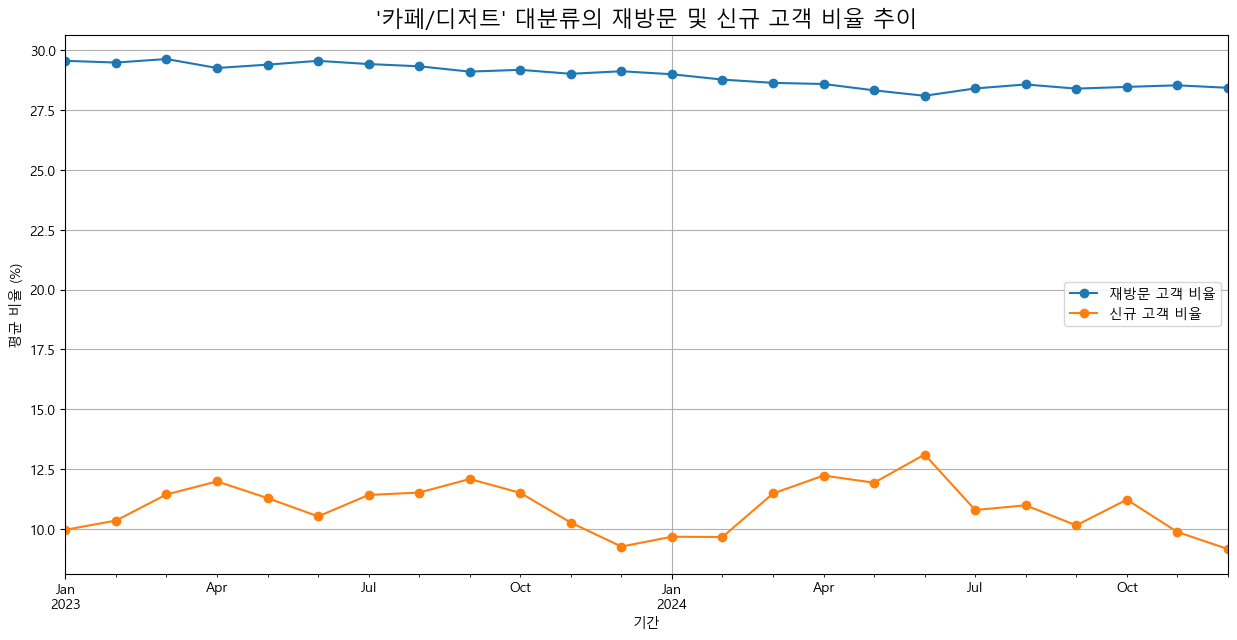

In [16]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '카페/디저트'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()

    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")


✅ '주류/유흥' 대분류로 필터링된 데이터 개수: 7659 개


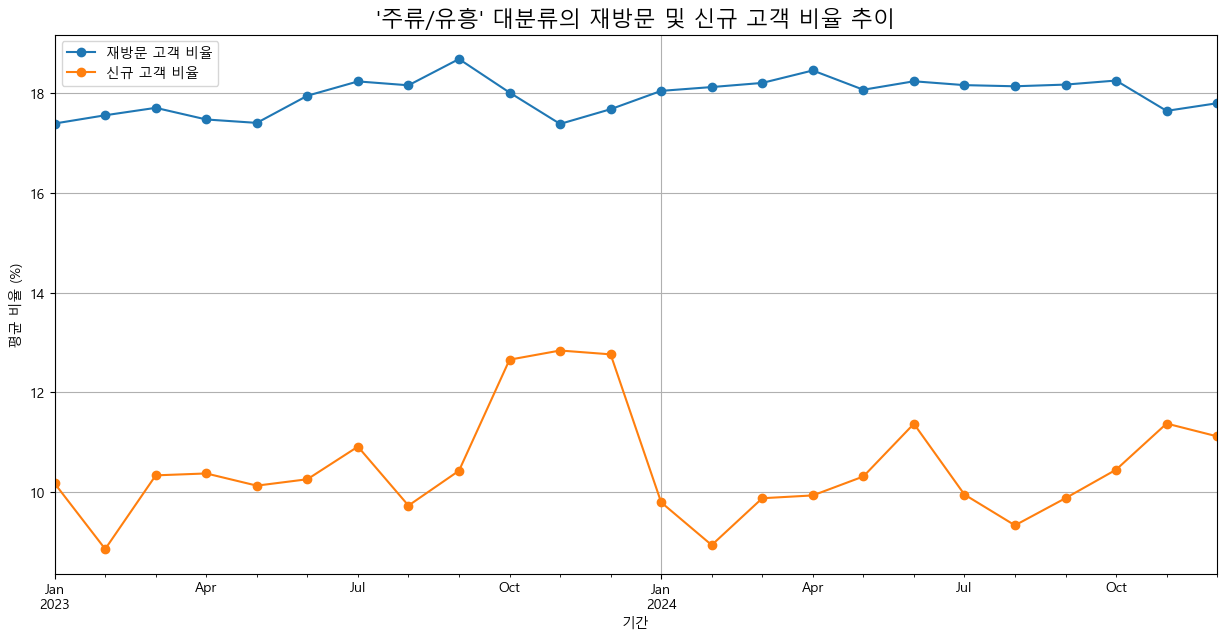

In [17]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '주류/유흥'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()

    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")


✅ '식료품/소매' 대분류로 필터링된 데이터 개수: 14296 개


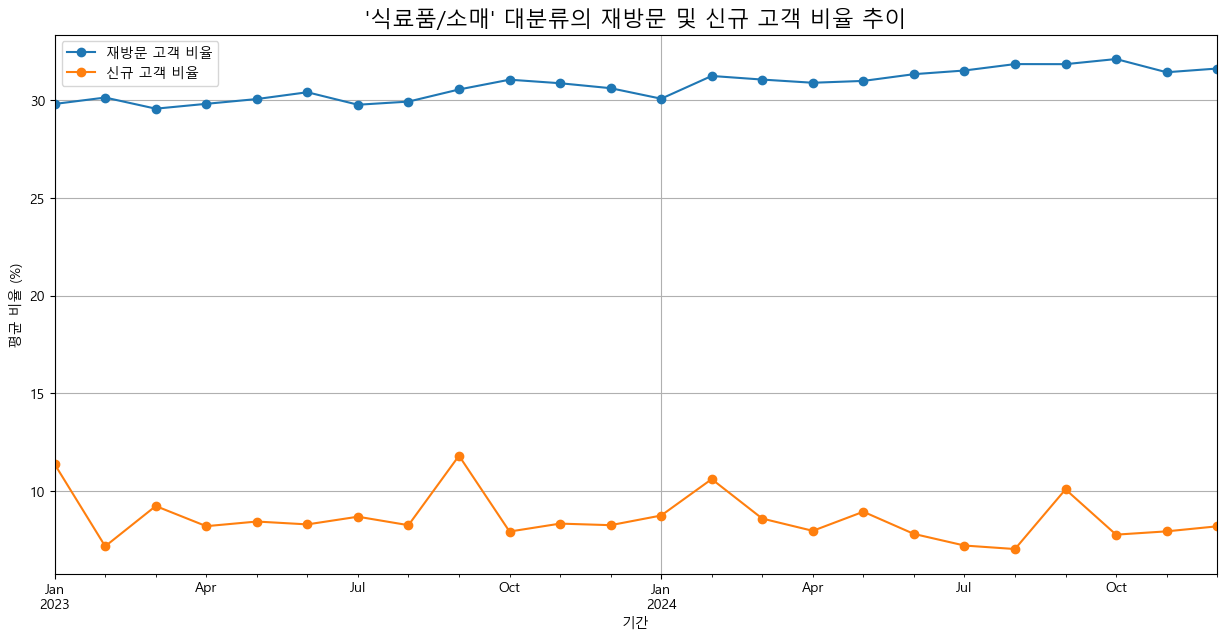

In [18]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '식료품/소매'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()

    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")


In [19]:
import matplotlib.pyplot as plt

# --- 1. 분석하고 싶은 대분류명 선택 ---
# '한식', '음식점', '카페/디저트', '주류/유흥', '식료품/소매', '기타' 중에서 선택하세요.
TARGET_CATEGORY = '기타'

# --- 2. '대분류' 컬럼으로 데이터 필터링 ---
# HPSN_MCT_BZN_CD_NM 대신 새로 만든 '대분류' 컬럼을 사용합니다.
category_df = final_df[final_df['대분류'] == TARGET_CATEGORY]

print(f"✅ '{TARGET_CATEGORY}' 대분류로 필터링된 데이터 개수: {len(category_df)} 개")

# --- 3. 월별 평균 계산 및 시각화 ---
if not category_df.empty:
    # 월별로 그룹화하여 평균을 계산합니다.
    category_trends = category_df.groupby('TA_YM')[['MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT']].mean()
    # 시각화
    category_trends.plot(figsize=(15, 7), marker='o')
    plt.title(f"'{TARGET_CATEGORY}' 대분류의 재방문 및 신규 고객 비율 추이", fontsize=16)
    plt.xlabel('기간')
    plt.ylabel('평균 비율 (%)')
    plt.legend(['재방문 고객 비율', '신규 고객 비율'])
    plt.grid(True)
    plt.show()
else:
    print(f"'{TARGET_CATEGORY}' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.")


✅ '기타' 대분류로 필터링된 데이터 개수: 0 개
'기타' 대분류에 해당하는 데이터가 없습니다. 대분류명을 확인해주세요.


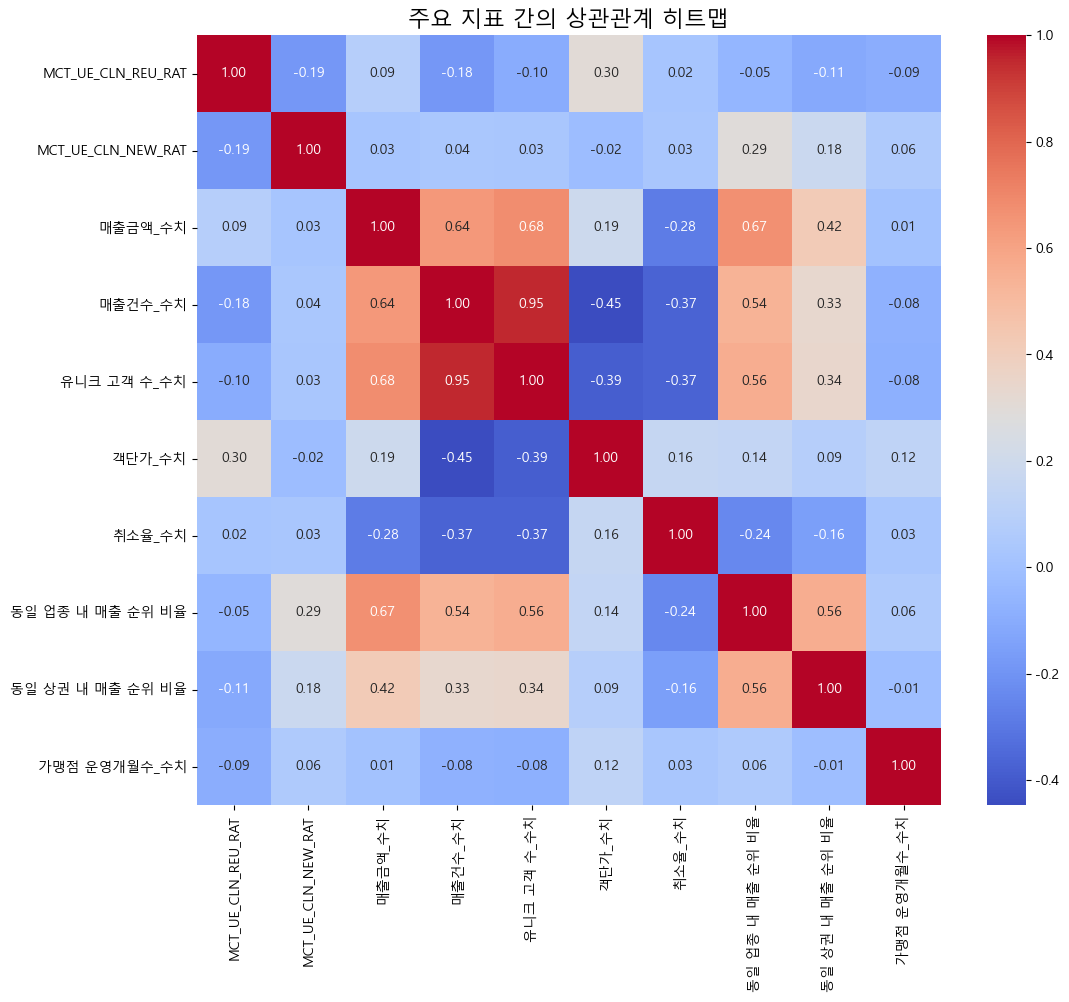

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상관관계 분석에 사용할 숫자형 컬럼들을 선택합니다.
numeric_columns = [
    'MCT_UE_CLN_REU_RAT',       # Y1: 재방문 고객 비율 (충성도)
    'MCT_UE_CLN_NEW_RAT',       # Y2: 신규 고객 비율 (유입)
    '매출금액_수치',
    '매출건수_수치',
    '유니크 고객 수_수치',
    '객단가_수치',
    '취소율_수치',             
    '동일 업종 내 매출 순위 비율', 
    '동일 상권 내 매출 순위 비율',
    '가맹점 운영개월수_수치'
]

# 상관계수 행렬을 계산합니다.
correlation_matrix = final_df[numeric_columns].corr()

# 히트맵으로 시각화합니다.
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True,      # 각 셀에 숫자 표시
    cmap='coolwarm', # 색상 맵 (파란색: 양, 빨간색: 음)
    fmt='.2f'        # 소수점 둘째 자리까지 표시
)
plt.title('주요 지표 간의 상관관계 히트맵', fontsize=16)
plt.show()


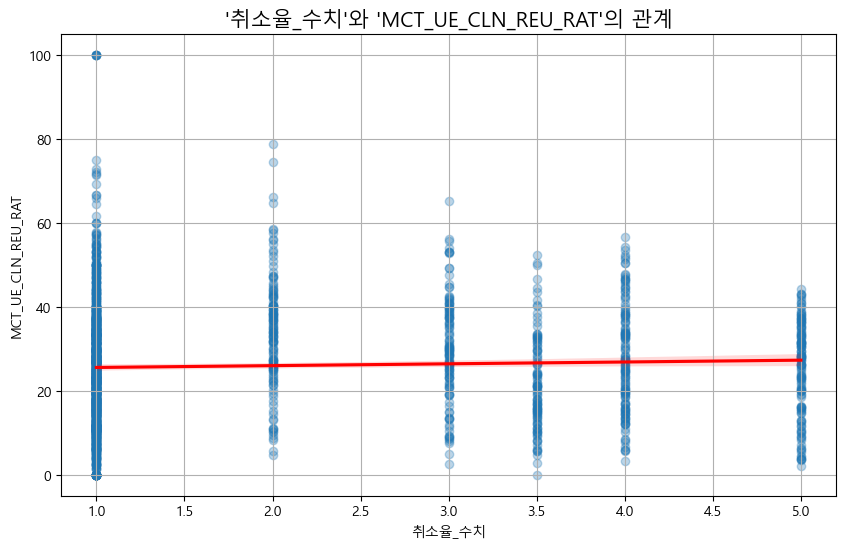

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 분석할 X, Y 변수 정의 ---
# 히트맵에서 찾은 가장 유력한 원인 변수를 X로 설정하세요.
X_VARIABLE = '취소율_수치'
Y_VARIABLE = 'MCT_UE_CLN_REU_RAT'

# 산점도(scatter plot)와 회귀선을 함께 그립니다.
plt.figure(figsize=(10, 6))
sns.regplot(
    data=final_df.sample(n=2000, random_state=42), # 데이터가 많으므로 샘플링하여 시각화
    x=X_VARIABLE,
    y=Y_VARIABLE,
    scatter_kws={'alpha':0.3}, # 점 투명도
    line_kws={'color':'red'}    # 회귀선 색상
)

plt.title(f"'{X_VARIABLE}'와 '{Y_VARIABLE}'의 관계", fontsize=15)
plt.xlabel(X_VARIABLE)
plt.ylabel(Y_VARIABLE)
plt.grid(True)
plt.show()


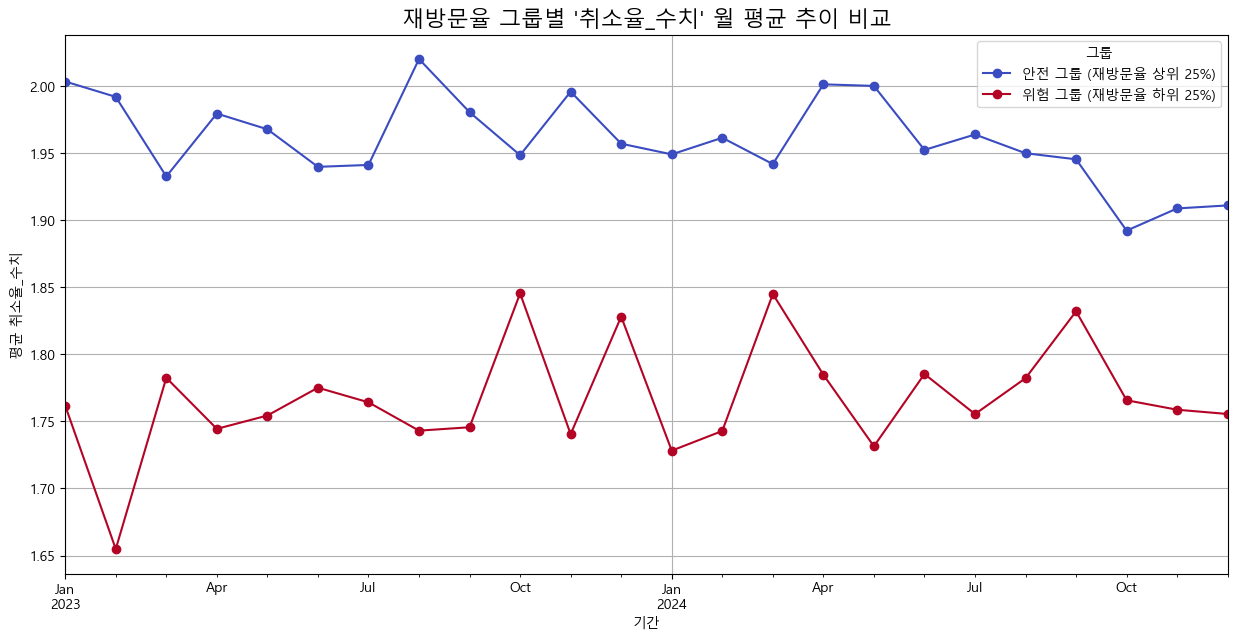

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 분석할 X, Y 변수 정의 ---
X_VARIABLE = '취소율_수치'
Y_VARIABLE = 'MCT_UE_CLN_REU_RAT'

# --- 2. Y 값을 기준으로 '위험 그룹'과 '안전 그룹' 나누기 ---
# 재방문율 하위 25%를 '위험 그룹', 상위 25%를 '안전 그룹'으로 정의
low_quantile = final_df[Y_VARIABLE].quantile(0.25)
high_quantile = final_df[Y_VARIABLE].quantile(0.75)

conditions = [
    final_df[Y_VARIABLE] <= low_quantile,
    final_df[Y_VARIABLE] >= high_quantile
]
choices = ['위험 그룹 (재방문율 하위 25%)', '안전 그룹 (재방문율 상위 25%)']
final_df['Group'] = np.select(conditions, choices, default=None)

# --- 3. 시간에 따른 그룹별 X 변수 평균 계산 ---
group_trends = final_df.dropna(subset=['Group']).groupby(['TA_YM', 'Group'])[X_VARIABLE].mean().unstack()

# --- 4. 시각화 ---
group_trends.plot(figsize=(15, 7), marker='o', colormap='coolwarm')

plt.title(f"재방문율 그룹별 '{X_VARIABLE}' 월 평균 추이 비교", fontsize=16)
plt.xlabel('기간')
plt.ylabel(f"평균 {X_VARIABLE}")
plt.legend(title='그룹')
plt.grid(True)
plt.show()


✅ '객단가_수치'와 'MCT_UE_CLN_REU_RAT'의 관계


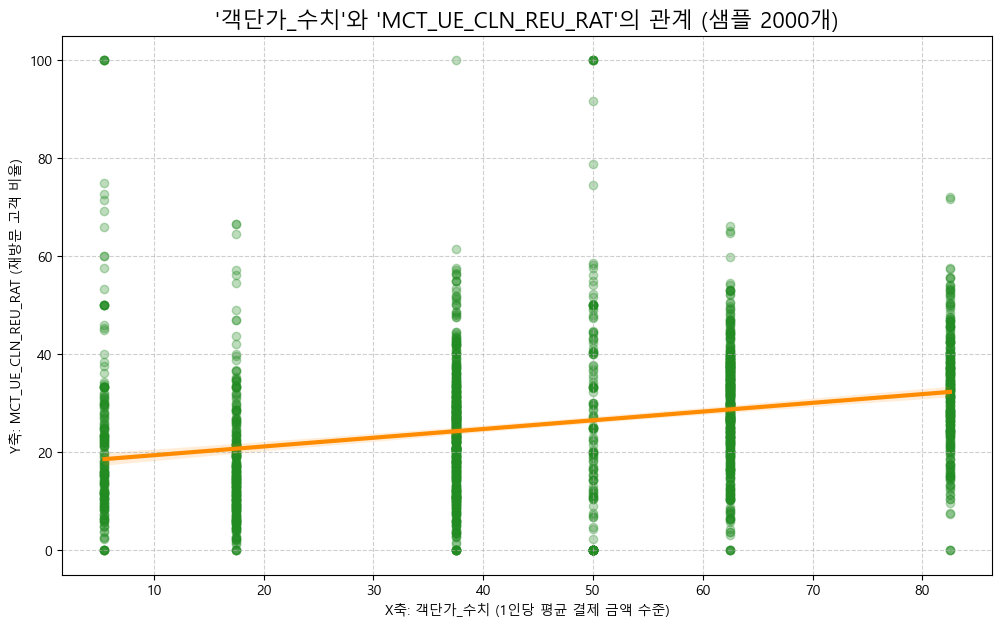

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 분석할 X, Y 변수 재설정 ---
# 히트맵에서 찾은 가장 유력한 긍정적 원인 변수인 '객단가_수치'를 X로 설정합니다.
X_VARIABLE = '객단가_수치'
Y_VARIABLE = 'MCT_UE_CLN_REU_RAT'

print(f"✅ '{X_VARIABLE}'와 '{Y_VARIABLE}'의 관계")

# --- 2. 산점도 및 회귀선 시각화 ---
plt.figure(figsize=(12, 7))

# 데이터가 많으므로 2000개를 샘플링하여 시각화합니다.
sns.regplot(
    data=final_df.sample(n=2000, random_state=42), 
    x=X_VARIABLE,
    y=Y_VARIABLE,
    scatter_kws={'alpha':0.3, 'color':'forestgreen'}, # 점의 투명도와 색상
    line_kws={'color':'darkorange', 'linewidth':3}   # 회귀선의 색상과 두께
)

plt.title(f"'{X_VARIABLE}'와 '{Y_VARIABLE}'의 관계 (샘플 2000개)", fontsize=16)
plt.xlabel(f"X축: {X_VARIABLE} (1인당 평균 결제 금액 수준)")
plt.ylabel(f"Y축: {Y_VARIABLE} (재방문 고객 비율)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
